# Training a Classifier

1. Load and normalize the CIFAR10 training and test datasets using torchvision
2. Define a Convolutional Neural Network
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data

## 1.Load and normalize CIFAR10

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [24]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
#transforms.Compose()
#https://pytorch.org/vision/stable/transforms.html?highlight=transforms%20compose#torchvision.transforms.Compose
#Composes several transforms together. 

#transforms.ToTensor()
#https://pytorch.org/vision/stable/transforms.html#torchvision.transforms.ToTensor
#Convert a PIL Image or numpy.ndarray to tensor.

#transforms.Normalize()
"""
Normalize a tensor image with mean and standard deviation. 
This transform does not support PIL Image. 
Given mean: (mean[1],...,mean[n]) and std: (std[1],..,std[n]) for n channels, 
this transform will normalize each channel of the input torch.*Tensor 
i.e., output[channel] = (input[channel] - mean[channel]) / std[channel]
"""

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,  shuffle=True, num_workers=2)
#https://pytorch.org/docs/stable/data.html?highlight=dataloader#torch.utils.data.DataLoader

testset = torchvision.datasets.CIFAR10(root='./data', train=False,  download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,  shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


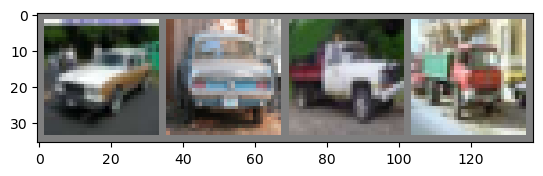

car   car   truck truck


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# function to show an image

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

# print labels
print(' '.join(f'{classes[labels[j].item()]:5s}' for j in range(min(batch_size, len(labels)))))

## 2.Define a Convolutional Neural Network

In [26]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5* 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
net = Net()

## 3.Define a Loss function and optimizer

In [27]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## 4.Train the network

In [28]:
for epoch in range(2):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the input; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        # print every 2000 mini-batches
        if i % 2000 == 1999:
            print(f'[{epoch + 1}， {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            runnig_loss = 0.0

print('Finished Training')

[1，  2000] loss: 2.210
[1，  4000] loss: 4.035
[1，  6000] loss: 5.668
[1，  8000] loss: 7.207
[1， 10000] loss: 8.696
[1， 12000] loss: 10.125
[2，  2000] loss: 1.378
[2，  4000] loss: 2.703
[2，  6000] loss: 4.019
[2，  8000] loss: 5.311
[2， 10000] loss: 6.606
[2， 12000] loss: 7.890
Finished Training


In [29]:
PATH = '/cifar_net.pth'
torch.save(net.state_dict(), PATH)

## 5.Test the network on the test data

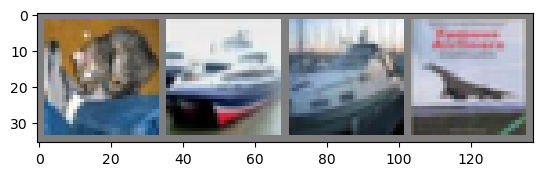

GroundTruth:  cat   ship  ship  plane


In [30]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print("GroundTruth: ", " ".join(f"{classes[labels[j]]:5s}" for j in range(4)))

In [31]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [32]:
outputs = net(images)

In [33]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(len(predicted))))

Predicted:  cat   ship  ship  ship 


In [34]:
correct = 0
total = 0
# since we are not training, we dont need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by outputing images through the network
        outputs = net(images)
        # the classes with the highest enrgy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the network on the 10000 test images: {100 * correct // total} %")

Accuracy of the network on the 10000 test images: 54 %


In [39]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, predictions, in zip(labels, predictions):
            if label == predictions:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count)/ total_pred[classname]
    print(f"Accuracy for class: {classname:5s} is {accuracy:.1f} %")

Accuracy for class: plane is 62.7 %
Accuracy for class: car   is 62.4 %
Accuracy for class: bird  is 26.7 %
Accuracy for class: cat   is 37.6 %
Accuracy for class: deer  is 62.4 %
Accuracy for class: dog   is 22.7 %
Accuracy for class: frog  is 60.5 %
Accuracy for class: horse is 74.1 %
Accuracy for class: ship  is 75.1 %
Accuracy for class: truck is 62.8 %


In [40]:
device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")

In [41]:
device

device(type='cuda', index=0)

In [42]:
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [43]:
inputs, labels = data[0].to(device), data[1].to(device)